# Práctica computacional
## Semana 2: Redes y Topología

> **MISE — Systems Analytics** | Universidad de los Andes

En esta sesión exploramos cómo modelar sistemas complejos como **redes** (grafos).
Veremos métricas de centralidad, topologías y —lo más importante— qué pasa
cuando algo falla en una red.

In [1]:
import sys; sys.path.insert(0, '.')
from mise_utils import viz, networks, energy_data
from mise_utils.viz import COLORS, plot_network, plot_degree_distribution
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt
viz.apply_mise_style()

---
## **Nivel 1 —** Nivel 1 — Intuición

*Construimos la intuición con redes pequeñas y ejemplos cotidianos.*

### 1.1 Tu primera red: 6 amigos

Seis personas (A–F) se conocen. Vamos a representar sus relaciones como un **grafo**.
Un grafo tiene **nodos** (personas) y **aristas** (relaciones).

In [2]:
# === TU PRIMERA RED ===
# Crear un grafo vacío
G6 = nx.Graph()

# Agregar nodos
G6.add_nodes_from(["A", "B", "C", "D", "E", "F"])

# Agregar aristas (conexiones)
G6.add_edges_from([
    ("A", "B"), ("A", "C"), ("A", "D"),
    ("B", "C"), ("B", "E"),
    ("C", "D"),
    ("D", "F")
])

print(f"Nodos: {G6.number_of_nodes()}")
print(f"Aristas: {G6.number_of_edges()}")
print(f"Grado de cada nodo: {dict(G6.degree())}")

Nodos: 6
Aristas: 7
Grado de cada nodo: {'A': 3, 'B': 3, 'C': 3, 'D': 3, 'E': 1, 'F': 1}


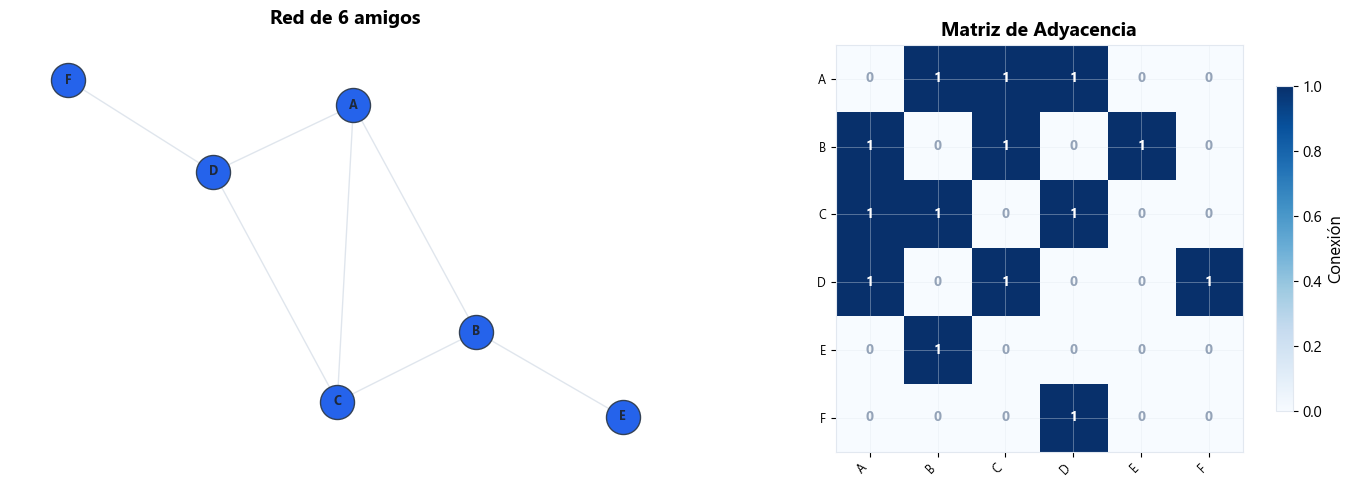

In [3]:
# Visualizar la red y su matriz de adyacencia
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Red
plot_network(G6, ax=axes[0], title="Red de 6 amigos", node_size_factor=600)

# Matriz de adyacencia
networks.mostrar_matriz_adyacencia(G6, ax=axes[1])

plt.tight_layout()
plt.show()

### 1.2 ¿Quién es más importante?

Hay muchas formas de medir la "importancia" de un nodo. Las cuatro métricas principales son:

| Métrica | ¿Qué mide? | Analogía |
|---------|-----------|----------|
| **Grado** | Número de conexiónes | ¿Cuántos amigos tienes? |
| **Betweenness** | Cuántos caminos cortos pasan por el nodo | ¿Eres un puente entre grupos? |
| **Closeness** | Qué tan cerca estás de todos | ¿Puedes llegar rápido a cualquiera? |
| **Clustering** | Qué tan conectados están tus vecinos entre sí | ¿Tus amigos son amigos entre sí? |

In [4]:
# Calcular las 4 métricas de centralidad
df_metricas = networks.calcular_todas_metricas(G6)
print("Métricas de centralidad para la red de 6 amigos:\n")
df_metricas

Métricas de centralidad para la red de 6 amigos:



,nodo,grado,betweenness,closeness,clustering
0,A,3,0.2,0.7143,0.6667
1,B,3,0.4,0.6250,0.3333
2,C,3,0.2,0.7143,0.6667
3,D,3,0.4,0.6250,0.3333
4,E,1,0.0,0.4167,0.0000
5,F,1,0.0,0.4167,0.0000


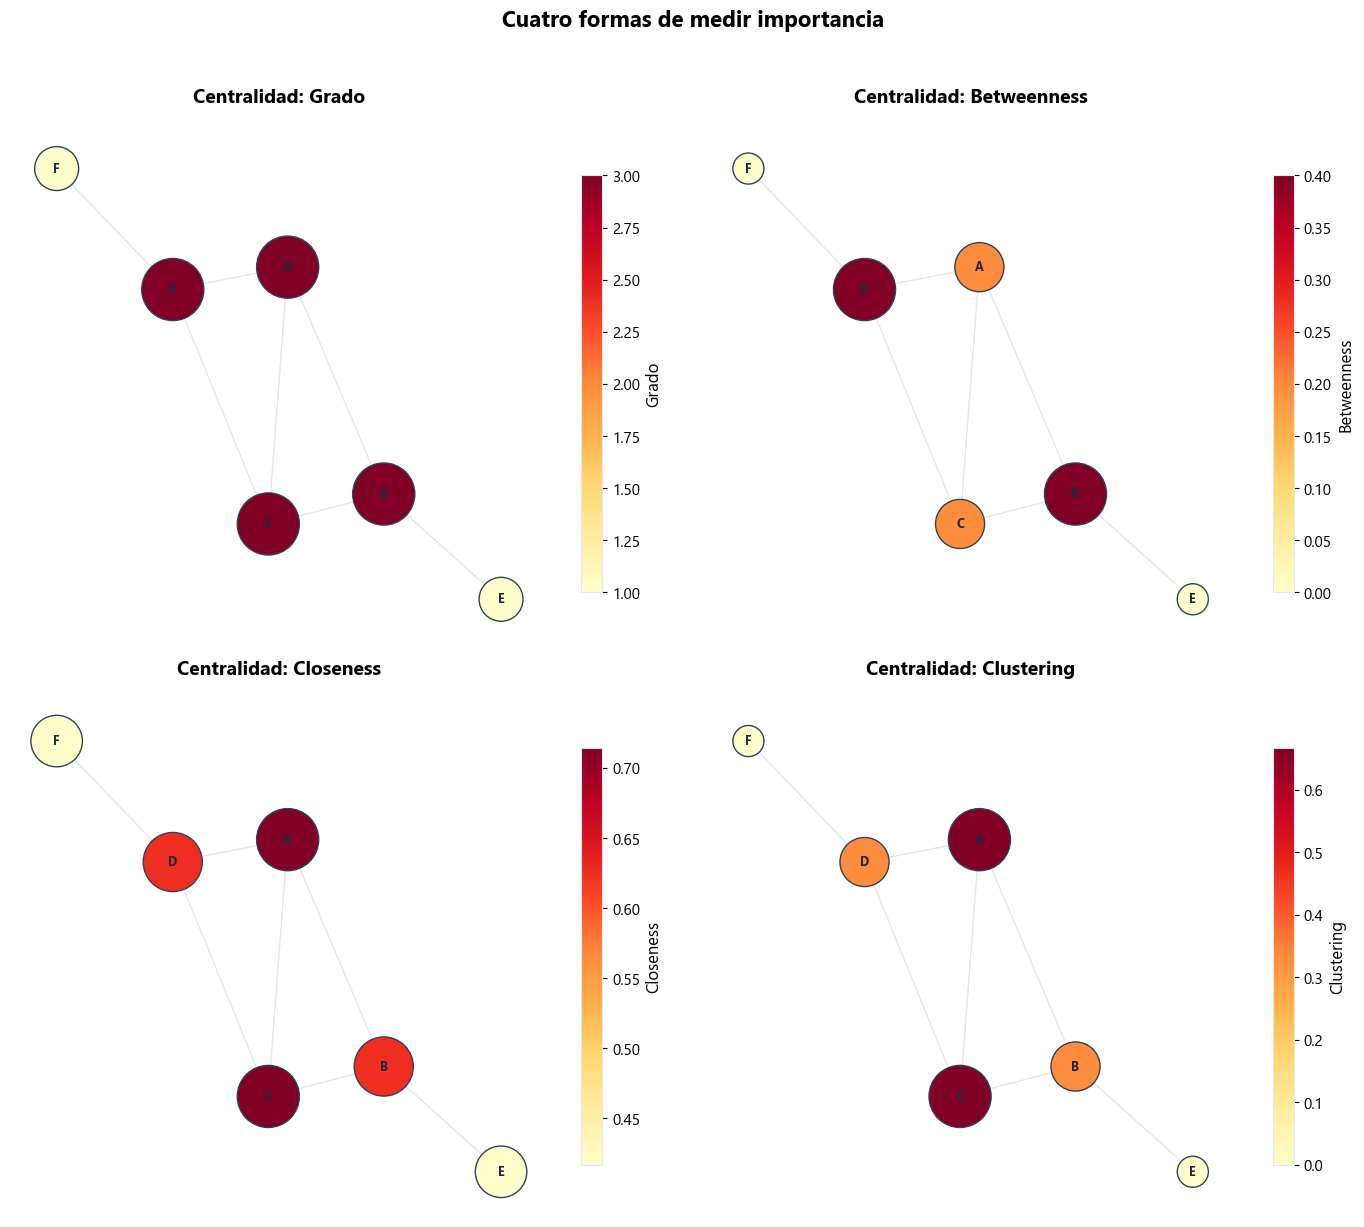

In [5]:
# Visualizar cada métrica como mapa de calor sobre la red
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

metricas = {
    "Grado": dict(G6.degree()),
    "Betweenness": nx.betweenness_centrality(G6),
    "Closeness": nx.closeness_centrality(G6),
    "Clustering": nx.clustering(G6),
}

pos = nx.spring_layout(G6, seed=42)

for ax, (nombre, valores) in zip(axes.flat, metricas.items()):
    plot_network(G6, metric_values=valores, metric_name=nombre,
                 layout=pos, ax=ax, title=f"Centralidad: {nombre}",
                 node_size_factor=500)

plt.suptitle("Cuatro formas de medir importancia", fontsize=16,
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

### 1.3 ¿Cómo se calcula betweenness?

La **betweenness centrality** mide cuántos caminos más cortos pasan por un nodo.
Es como contar cuántas veces eres "puente" entre otros dos nodos.

Veamos el algoritmo paso a paso:

In [6]:
# Algoritmo de betweenness — versión pedagógica
def betweenness_paso_a_paso(G):
    """Calcula betweenness centrality paso a paso (versión didáctica)."""
    betweenness = {v: 0 for v in G.nodes()}
    nodos = list(G.nodes())

    for s in nodos:
        for t in nodos:
            if s != t:
                # Encontrar todos los caminos más cortos de s a t
                try:
                    caminos = list(nx.all_shortest_paths(G, s, t))
                    for camino in caminos:
                        for v in camino[1:-1]:  # nodos intermedios
                            betweenness[v] += 1.0 / len(caminos)
                except nx.NetworkXNoPath:
                    pass

    # Normalizar
    n = len(nodos)
    for v in betweenness:
        betweenness[v] /= ((n - 1) * (n - 2) / 2)

    return betweenness

# Comparar nuestra versión con la de NetworkX
bc_manual = betweenness_paso_a_paso(G6)
bc_nx = nx.betweenness_centrality(G6)

print("Comparación betweenness (manual vs NetworkX):")
print(f"{'Nodo':<6} {'Manual':>10} {'NetworkX':>10} {'¿Iguales?':>10}")
print("-" * 40)
for nodo in sorted(G6.nodes()):
    m = round(bc_manual[nodo], 4)
    n_val = round(bc_nx[nodo], 4)
    ok = "" if abs(m - n_val) < 0.001 else ""
    print(f"{nodo:<6} {m:>10.4f} {n_val:>10.4f} {ok:>10}")

Comparación betweenness (manual vs NetworkX):
Nodo       Manual   NetworkX  ¿Iguales?
----------------------------------------
A          0.4000     0.2000           
B          0.8000     0.4000           
C          0.4000     0.2000           
D          0.8000     0.4000           
E          0.0000     0.0000           
F          0.0000     0.0000           


### 1.4 Tres mundos de redes

No todas las redes son iguales. Existen tres modelos fundamentales:

| Modelo | Idea clave | ¿Dónde se ve? |
|--------|-----------|---------------|
| **Erdős-Rényi** | Conexiónes al azar | Línea base teórica |
| **Barabási-Albert** | "El rico se hace más rico" | Internet, aeropuertos |
| **Watts-Strogatz** | Amigos de amigos + atajos | Redes sociales |

In [7]:
# Algoritmo de Barabási-Albert — paso a paso
def barabasi_albert_manual(n, m, seed=42):
    """Construye una red scale-free usando preferential attachment."""
    rng = np.random.default_rng(seed)
    G = nx.complete_graph(m)  # Empezar con grafo completo de m nodos

    for nuevo_nodo in range(m, n):
        # Probabilidad proporcional al grado ("el rico se hace más rico")
        grados = np.array([G.degree(v) for v in G.nodes()])
        probabilidades = grados / grados.sum()

        # Elegir m nodos existentes para conectar
        elegidos = rng.choice(list(G.nodes()), size=m, replace=False,
                              p=probabilidades)

        G.add_node(nuevo_nodo)
        for v in elegidos:
            G.add_edge(nuevo_nodo, v)

    return G

# Generar una red scale-free con nuestro algoritmo
G_manual = barabasi_albert_manual(100, 3)
print(f"Red Barabási-Albert manual: {G_manual.number_of_nodes()} nodos, "
      f"{G_manual.number_of_edges()} aristas")
print(f"Grado máximo: {max(dict(G_manual.degree()).values())}")
print(f"Grado medio: {np.mean(list(dict(G_manual.degree()).values())):.1f}")

Red Barabási-Albert manual: 100 nodos, 294 aristas
Grado máximo: 26
Grado medio: 5.9


C:\Users\ch.gomez171\Documents\GitHub\Systems_Analytics_MISE\notebooks\mise_utils\networks.py:279: UserWarning: Glyph 10216 (\N{MATHEMATICAL LEFT ANGLE BRACKET}) missing from current font.
  fig.tight_layout()
C:\Users\ch.gomez171\Documents\GitHub\Systems_Analytics_MISE\notebooks\mise_utils\networks.py:279: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from current font.
  fig.tight_layout()
C:\Users\ch.gomez171\AppData\Local\Anaconda3new\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 10216 (\N{MATHEMATICAL LEFT ANGLE BRACKET}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ch.gomez171\AppData\Local\Anaconda3new\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 10217 (\N{MATHEMATICAL RIGHT ANGLE BRACKET}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


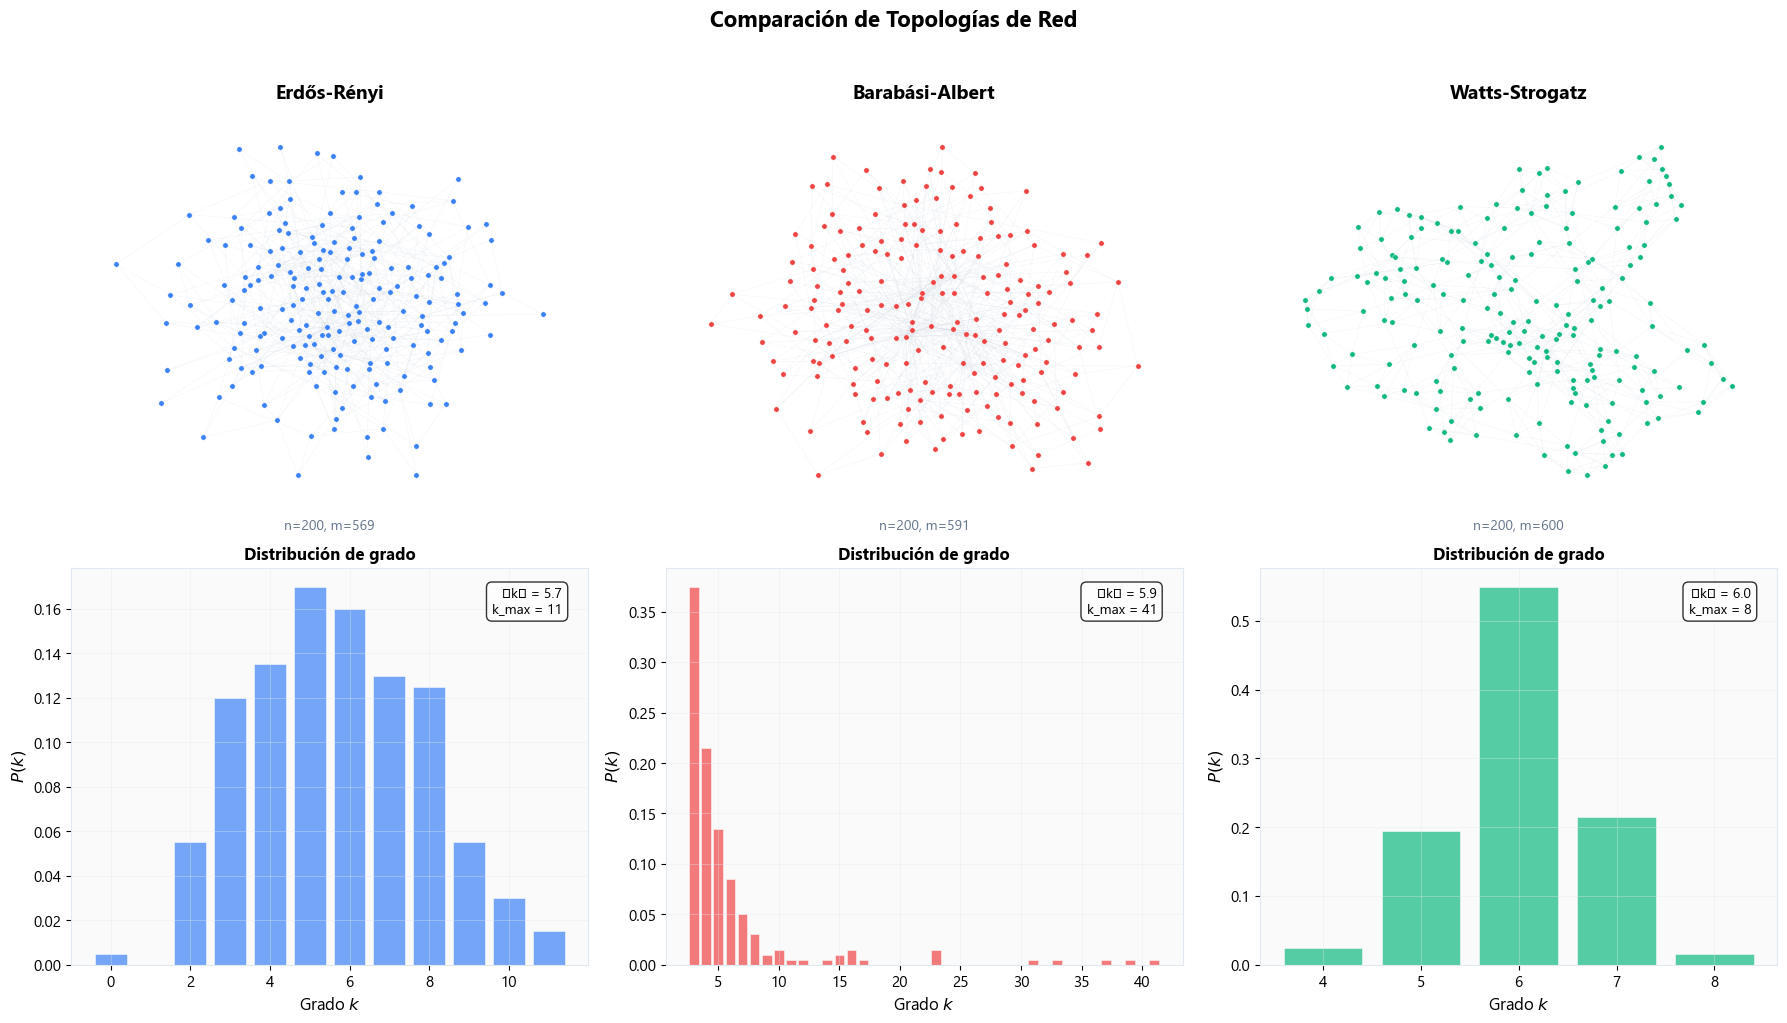

In [8]:
# Generar las tres topologías clásicas
redes = networks.generar_tres_topologias(n=200, seed=42)

# Comparación visual
fig = networks.comparar_topologias(redes)
plt.show()

In [9]:
# Tabla comparativa de métricas
df_topo = networks.tabla_comparacion_topologias(redes)
print("Comparación de topologías:\n")
df_topo

Comparación de topologías:



,Nodos,Aristas,⟨k⟩ Grado medio,k_max,Clustering,Camino medio,Componentes
Topología,,,,,,,
Erdős-Rényi,200,569,5.69,11,0.0395,3.227,2
Barabási-Albert,200,591,5.91,41,0.1023,2.835,1
Watts-Strogatz,200,600,6.00,8,0.4379,4.415,1


> **Nota:** **Observación clave**: Barabási-Albert tiene pocos nodos con grado MUY alto (hubs)
> y muchos nodos con grado bajo. Watts-Strogatz tiene alto clustering.
> Erdős-Rényi es el "control" — todo es homogéneo.

### 1.5 Robusto pero frágil

Las redes scale-free (como las de aeropuertos) son **robustas** ante fallas aleatorias
pero **frágiles** ante ataques dirigidos a los hubs.

Esto se llama la **propiedad "robust yet fragile"** (Albert et al., 2000).

Red de aeropuertos: 100 nodos, 196 aristas


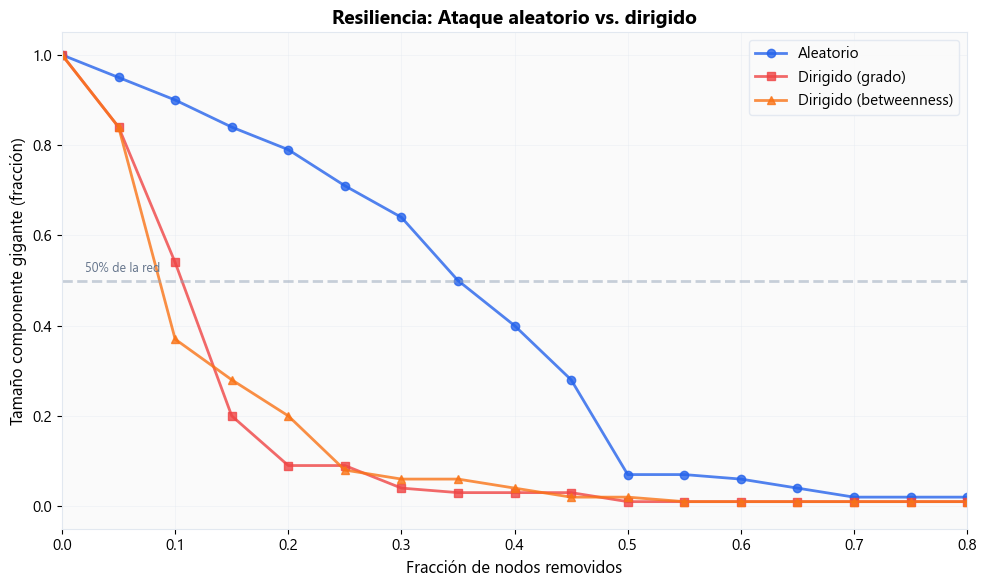

In [10]:
# Crear red de aeropuertos (scale-free)
G_aero = networks.crear_red_aeropuertos(n=100, seed=42)
print(f"Red de aeropuertos: {G_aero.number_of_nodes()} nodos, "
      f"{G_aero.number_of_edges()} aristas")

# Comparar resiliencia
fig = networks.comparar_resiliencia(G_aero, seed=42)
plt.show()

>  **Interpretación**: Con ataque **aleatorio**, la red aguanta la eliminación
> de ~40% de los nodos sin colapsar. Pero con ataque **dirigido** a los hubs,
> basta con eliminar ~15% para destruir la conectividad.

---
## **Nivel 2 —** Nivel 2 — Energía

*Aplicamos los conceptos al Sistema Interconectado Nacional (SIN) de Colombia.*

### 2.1 El SIN como grafo

El Sistema Interconectado Nacional (SIN) conecta las regiones de Colombia
mediante líneas de transmisión de alta tensión. Modelemos esta red como un grafo.

> [WARN] **Nota**: Esta es una representación simplificada y pedagógica del SIN.
> Para datos reales, consultar [XM](https://www.xm.com.co).

Red SIN simplificada: 45 nodos, 52 aristas
Regiones: ['Antioquia', 'Arauca', 'Boyacá', 'Caldas', 'Cauca', 'Cesar', 'Costa', 'Cundinamarca', 'Córdoba', 'Guajira', 'Huila', 'Meta', 'N. Santander', 'Nariño', 'Risaralda', 'Santander', 'Tolima', 'Valle']


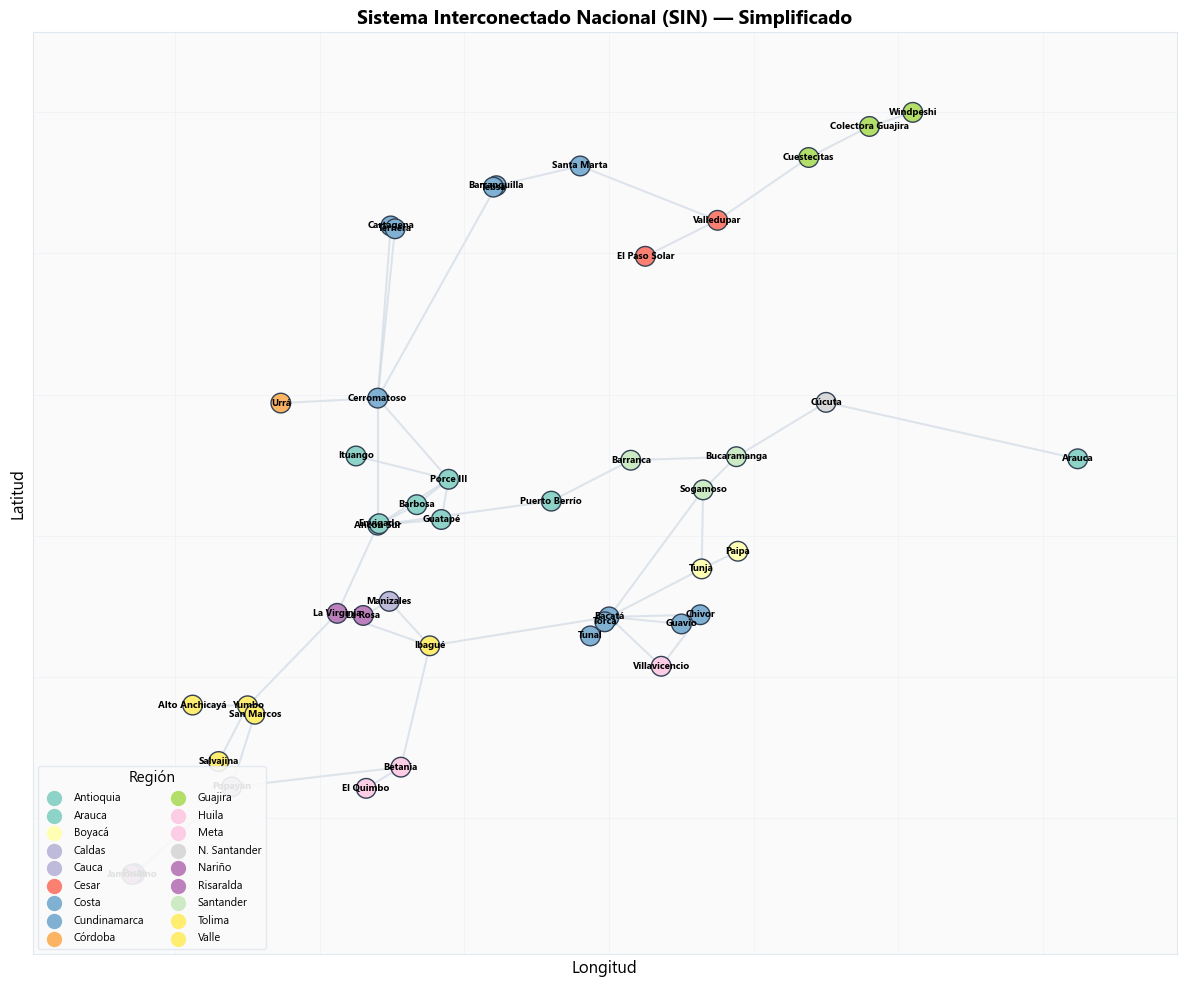

In [11]:
# Cargar la red del SIN
G_sin = energy_data.crear_red_sin_simplificada()

print(f"Red SIN simplificada: {G_sin.number_of_nodes()} nodos, "
      f"{G_sin.number_of_edges()} aristas")
print(f"Regiones: {sorted(set(nx.get_node_attributes(G_sin, 'region').values()))}")

# Visualizar con posiciones geográficas (lat/lon)
pos_geo = {n: (G_sin.nodes[n]["lon"], G_sin.nodes[n]["lat"])
           for n in G_sin.nodes()}

# Colorear por región
regiones = nx.get_node_attributes(G_sin, "region")
regiones_unicas = sorted(set(regiones.values()))
colores_region = plt.cm.Set3(np.linspace(0, 1, len(regiones_unicas)))
mapa_color = {r: colores_region[i] for i, r in enumerate(regiones_unicas)}
node_colors = [mapa_color[regiones[n]] for n in G_sin.nodes()]

fig, ax = plt.subplots(figsize=(12, 10))
nx.draw_networkx_edges(G_sin, pos_geo, ax=ax,
                       edge_color=COLORS["edge_default"],
                       width=1.5, alpha=0.6)
nx.draw_networkx_nodes(G_sin, pos_geo, ax=ax,
                       node_color=node_colors, node_size=200,
                       edgecolors="#334155", linewidths=1.0)
nx.draw_networkx_labels(G_sin, pos_geo, ax=ax,
                        font_size=7, font_weight="bold")

# Leyenda de regiones
for region, color in mapa_color.items():
    ax.scatter([], [], c=[color], s=100, label=region)
ax.legend(loc="lower left", fontsize=8, ncol=2, title="Región")

ax.set_title("Sistema Interconectado Nacional (SIN) — Simplificado",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")
plt.tight_layout()
plt.show()

### 2.2 Cuellos de botella del SIN

¿Cuáles son los nodos más críticos del SIN? Usamos **betweenness centrality**
para identificar los "cuellos de botella" — nodos por los que pasan muchos caminos.

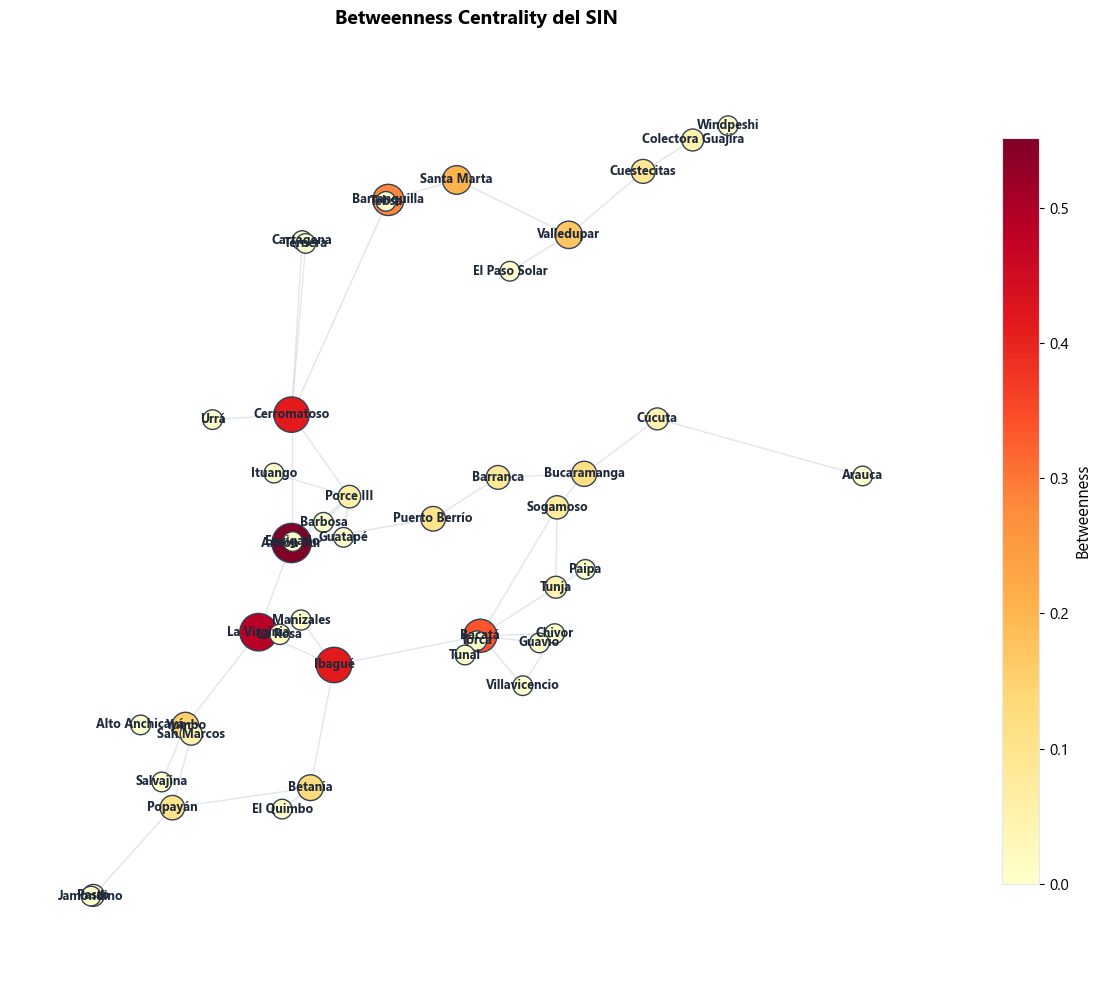


**Nivel 3 —** Top 5 nodos con mayor betweenness (cuellos de botella):
       nodo  grado  betweenness
  Ancón Sur      7       0.5514
La Virginia      4       0.4861
     Ibagué      4       0.4131
Cerromatoso      6       0.4123
     Bacatá      8       0.3402


In [12]:
# Calcular betweenness para el SIN
bc_sin = nx.betweenness_centrality(G_sin)

# Visualizar betweenness como mapa de calor
fig, ax = plt.subplots(figsize=(12, 10))
plot_network(G_sin, metric_values=bc_sin, metric_name="Betweenness",
             layout=pos_geo, ax=ax,
             title="Betweenness Centrality del SIN",
             show_labels=True, node_size_factor=200)
plt.tight_layout()
plt.show()

# Top 5 nodos más críticos
df_sin = networks.calcular_todas_metricas(G_sin)
print("\n**Nivel 3 —** Top 5 nodos con mayor betweenness (cuellos de botella):")
print(df_sin.nlargest(5, "betweenness")[["nodo", "grado", "betweenness"]].to_string(index=False))

### 2.3 N-1 vs. Ataque dirigido

El criterio **N-1** dice que el sistema debe operar correctamente
si se pierde **un** componente cualquiera. Comparemos qué pasa cuando:
1. Se pierde un nodo **aleatorio**
2. Se pierde el nodo de **mayor betweenness**

In [13]:
# Simular N-1: pérdida de un nodo aleatorio vs. el más crítico
nodo_critico = max(bc_sin, key=bc_sin.get)

rng = np.random.default_rng(42)
nodos_lista = list(G_sin.nodes())
nodo_aleatorio = rng.choice(nodos_lista)

print(f"Nodo aleatorio seleccionado: {nodo_aleatorio}")
print(f"Nodo más crítico (betweenness): {nodo_critico}")
print()

for nombre, nodo in [("Aleatorio", nodo_aleatorio), ("Más crítico", nodo_critico)]:
    G_test = G_sin.copy()
    G_test.remove_node(nodo)
    n_comp = nx.number_connected_components(G_test)
    if n_comp > 0:
        giant = max(len(c) for c in nx.connected_components(G_test))
    else:
        giant = 0
    pct = giant / G_sin.number_of_nodes() * 100
    print(f"Removiendo {nombre} ({nodo}):")
    print(f"  Componentes: {n_comp}")
    print(f"  Componente gigante: {giant} nodos ({pct:.1f}% del original)")
    print()

Nodo aleatorio seleccionado: Ituango
Nodo más crítico (betweenness): Ancón Sur

Removiendo Aleatorio (Ituango):
  Componentes: 1
  Componente gigante: 44 nodos (97.8% del original)

Removiendo Más crítico (Ancón Sur):
  Componentes: 3
  Componente gigante: 27 nodos (60.0% del original)



### 2.4 Simulación de cascada

Cuando un nodo falla, su **carga** (flujo de potencia) se redistribuye.
Si otros nodos quedan sobrecargados, también fallan. Esto es una **cascada**.

Usamos el modelo **Motter-Lai** (2002):
- Carga = betweenness centrality
- Capacidad = (1 + α) × carga inicial
- Si carga > capacidad → falla

In [14]:
# Simulación de cascada (Motter-Lai) — paso a paso
def cascada_paso_a_paso(G, nodo_falla, alpha=0.2):
    """Simula una cascada de fallas usando el modelo Motter-Lai."""
    G_work = G.copy()

    # Paso 1: Calcular carga inicial (betweenness)
    carga_inicial = nx.betweenness_centrality(G_work)

    # Paso 2: Definir capacidad con margen de tolerancia
    capacidad = {v: (1 + alpha) * carga_inicial[v] for v in G_work}

    # Paso 3: Falla inicial
    fallados = {nodo_falla}
    G_work.remove_node(nodo_falla)
    historial = [fallados.copy()]

    print(f"Paso 0: Falla inicial de '{nodo_falla}'")
    print(f"  Nodos fallados: {len(fallados)}")

    paso = 0
    while True:
        paso += 1
        # Recalcular carga después de las fallas
        carga_actual = nx.betweenness_centrality(G_work)

        # Detectar nodos sobrecargados
        nuevos_fallados = set()
        for v in list(G_work.nodes()):
            if carga_actual.get(v, 0) > capacidad.get(v, 0):
                nuevos_fallados.add(v)

        if not nuevos_fallados:
            print(f"\nPaso {paso}: Sin nuevas fallas — cascada detenida ")
            break

        fallados |= nuevos_fallados
        for v in nuevos_fallados:
            G_work.remove_node(v)
        historial.append(fallados.copy())

        print(f"Paso {paso}: {len(nuevos_fallados)} nodos sobrecargados → "
              f"{len(fallados)} fallas totales")

    return historial

# Ejecutar cascada desde el nodo más crítico
print("=" * 55)
print("  CASCADA EN EL SIN (modelo Motter-Lai, α = 0.2)")
print("=" * 55)
print()
historial = cascada_paso_a_paso(G_sin, nodo_critico, alpha=0.2)
print(f"\nResultado final: {len(historial[-1])} de "
      f"{G_sin.number_of_nodes()} nodos fallaron "
      f"({len(historial[-1])/G_sin.number_of_nodes()*100:.1f}%)")

  CASCADA EN EL SIN (modelo Motter-Lai, α = 0.2)

Paso 0: Falla inicial de 'Ancón Sur'
  Nodos fallados: 1
Paso 1: 2 nodos sobrecargados → 3 fallas totales

Paso 2: Sin nuevas fallas — cascada detenida 

Resultado final: 3 de 45 nodos fallaron (6.7%)


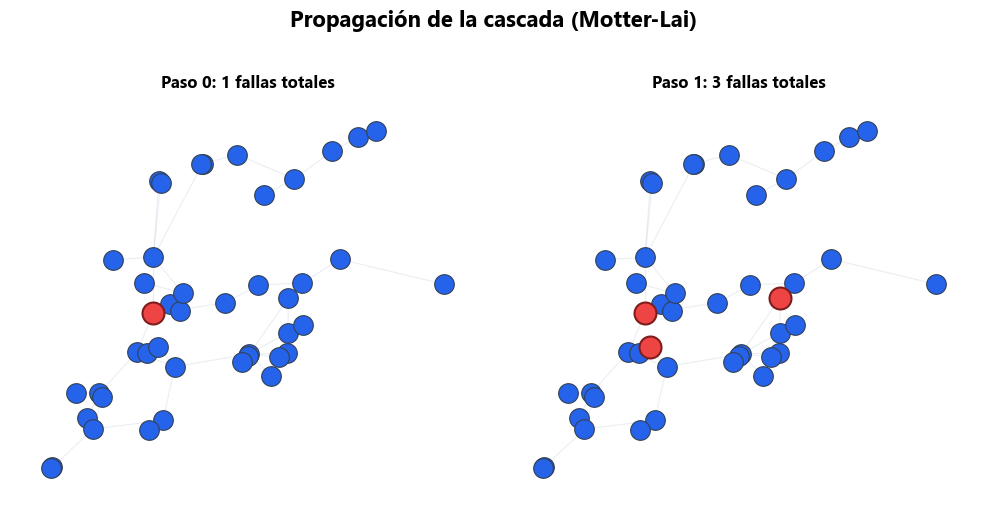

In [15]:
# Visualizar la cascada usando la función del módulo
cascada_res = networks.simular_cascada(G_sin, nodo_critico, alpha=0.2)
fig = networks.plot_cascada_pasos(G_sin, cascada_res, layout=pos_geo)
plt.show()

### 2.5 ¿Qué cambia con La Guajira?

La Guajira es la nueva frontera renovable de Colombia (eólica y solar).
Sus nodos están conectados de forma **radial** al resto del SIN.

¿Qué pasa si removemos los nodos de La Guajira?

Nodos de La Guajira: ['Cuestecitas', 'Colectora Guajira', 'Windpeshi']


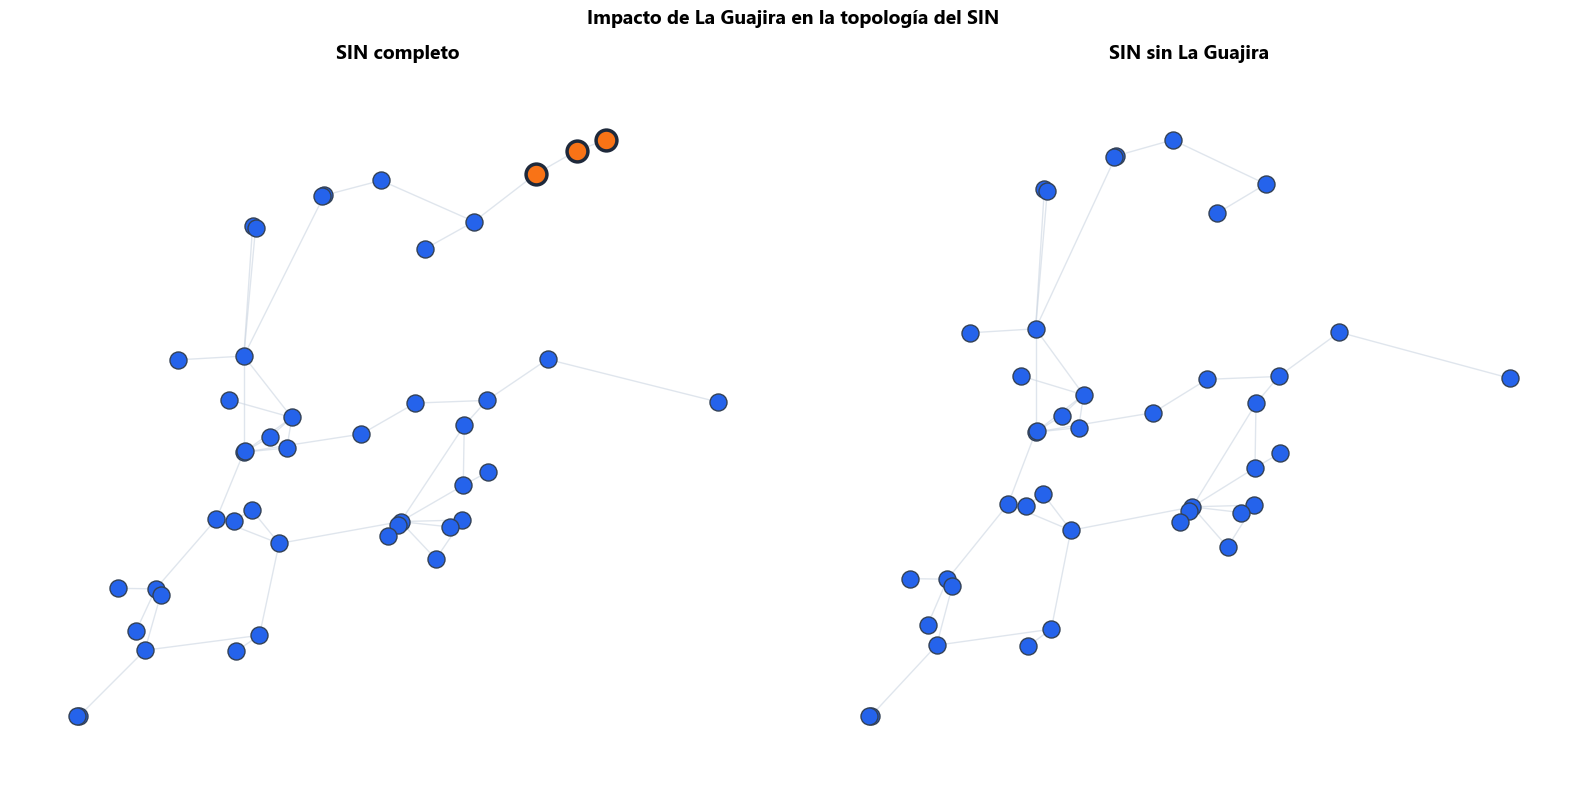


Comparación:
Métrica                            Con Guajira     Sin Guajira
------------------------------------------------------------
Nodos                                       45              42
Aristas                                     52              49
Clustering medio                        0.1166          0.1249
Componentes                                  1               1


In [16]:
# Identificar nodos de La Guajira
nodos_guajira = [n for n, d in G_sin.nodes(data=True)
                 if d.get("region") == "Guajira"]
print(f"Nodos de La Guajira: {nodos_guajira}")

# Crear SIN sin La Guajira
G_sin_no_guajira = G_sin.copy()
G_sin_no_guajira.remove_nodes_from(nodos_guajira)

# Comparar
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Con Guajira
plot_network(G_sin, layout=pos_geo, ax=axes[0],
             title="SIN completo", show_labels=False,
             node_size_factor=150,
             highlight_nodes=nodos_guajira,
             highlight_color=COLORS["warning"])

# Sin Guajira
pos_geo_sin_g = {n: pos_geo[n] for n in G_sin_no_guajira.nodes()}
plot_network(G_sin_no_guajira, layout=pos_geo_sin_g, ax=axes[1],
             title="SIN sin La Guajira", show_labels=False,
             node_size_factor=150)

plt.suptitle("Impacto de La Guajira en la topología del SIN",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Métricas comparativas
print("\nComparación:")
print(f"{'Métrica':<30} {'Con Guajira':>15} {'Sin Guajira':>15}")
print("-" * 60)
print(f"{'Nodos':<30} {G_sin.number_of_nodes():>15} "
      f"{G_sin_no_guajira.number_of_nodes():>15}")
print(f"{'Aristas':<30} {G_sin.number_of_edges():>15} "
      f"{G_sin_no_guajira.number_of_edges():>15}")
print(f"{'Clustering medio':<30} {nx.average_clustering(G_sin):>15.4f} "
      f"{nx.average_clustering(G_sin_no_guajira):>15.4f}")
print(f"{'Componentes':<30} "
      f"{nx.number_connected_components(G_sin):>15} "
      f"{nx.number_connected_components(G_sin_no_guajira):>15}")

---
## **Nivel 3 —** Nivel 3 — Profesional

*Para ir más allá: literatura y herramientas avanzadas.*

### 3.1 Lectura recomendada: Resiliencia de redes

 **Papers fundamentales:**

1. **Albert, R., Jeong, H., & Barabási, A.-L. (2000)**. "Error and attack tolerance of complex networks." *Nature*, 406, 378-382.
   — El paper que demostró la propiedad "robust yet fragile" de las redes scale-free.

2. **Motter, A. E., & Lai, Y.-C. (2002)**. "Cascade-based attacks on complex networks." *Physical Review E*, 66(6), 065102.
   — El modelo de cascada que implementamos en este notebook.

3. **Buldyrev, S. V., et al. (2010)**. "Catastrophic cascade of failures in interdependent networks." *Nature*, 464, 1025-1028.
   — Extensión a redes interdependientes (e.g., eléctrica + telecomunicaciónes).

 **Recursos adicionales:**

- [Colorado State Power Systems Resilience](https://www.engr.colostate.edu/) — Grupo de investigación en resiliencia
- [Resiltech](https://www.resiltech.com/) — Herramientas de análisis de resiliencia
- [NetworkX Documentation](https://networkx.org/) — Librería que usamos en este curso

### 3.2 Casos de prueba IEEE

Para análisis profesional de redes eléctricas, la IEEE proporciona casos de prueba estándar:

| Caso | Descripción | Nodos | Uso |
|------|-----------|-------|-----|
| IEEE 14-bus | Red pequeña de prueba | 14 | Validación de algoritmos |
| IEEE 30-bus | Red de tamaño medio | 30 | Estudios de flujo de carga |
| IEEE 118-bus | Red grande realista | 118 | Análisis de contingencia |
| IEEE 300-bus | Red muy grande | 300 | Benchmarking computacional |

>  **Para usar**: Los archivos de datos IEEE se pueden cargar con
> [PYPOWER](https://github.com/rwl/PYPOWER) o [pandapower](https://www.pandapower.org/).

---
##  Cierre de la Semana 2

### Lo que aprendimos:

1. **Representar** un sistema como red (nodos + aristas + atributos)
2. **Medir** importancia con 4 métricas de centralidad
3. **Distinguir** 3 tipos de topología y sus propiedades
4. **Evaluar** resiliencia ante fallas aleatorias vs. ataques dirigidos
5. **Simular** cascadas de fallas con el modelo Motter-Lai
6. **Aplicar** todo esto al SIN de Colombia

### Para la Semana 3: Difusión y Contagio

- ¿Cómo se **propaga** una innovación (paneles solares) por una red social?
- ¿Qué determina si una tecnología se adopta masivamente o muere?
- Modelos de Bass, umbrales y epidemiológicos (SIR/SIS)

>  *"Las redes no solo importan por su estructura — importan por lo que fluye a través de ellas."*